# 6.TD方法

使用蒙特卡洛方法可以在不使用环境模型的情况下对策略进行评估，而且通过交替重复地评估和改进，可以得到最优策略或接近最优的策略。  
不过蒙特卡洛方法只有在达到回合终点时更新价值函数。  
本章将介绍一种不使用环境模型，而且每次采取行动时都会更新价值函数的方法，即`TD`方法（`Temporal Difference`）

## 6.1 使用TD方法评估策略


### 6.1.1 TD方法的推导

我们对收益的定义如下：
$$
\begin{align}
G_t &= R_t + \gamma R_{t+1} + \gamma^2 R_{t+2} + ... \\
&= R_t + \gamma G_{t+1}
\end{align}
$$
对价值函数做如下定义
$$
\begin{align}
v_\pi(s) &= \mathbb{E}_\pi[G_t|S_t=s] \tag{1-1} \\ 
&= \mathbb{E}_\pi[R_t + \gamma G_{t+1}|S_t=s] \tag{1-2}
\end{align}
$$
- (1-1)可推导使用蒙特卡洛方法（MC）的式子
- (1-2)可推导使用动态规划法（DP）的式子


In [2]:
from collections import defaultdict
import numpy as np
from res.common.gridworld import GridWorld
class TdAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.01
        self.action_szie = 4

        random_actions = {0:0.25, 1:0.25, 2:0.25, 3:0.25}
        self.pi = defaultdict(lambda:random_actions)
        self.V = defaultdict(lambda:0)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state]
        target = reward + self.gamma * next_V

        self.V[state] += (target - self.V[state]) * self.alpha

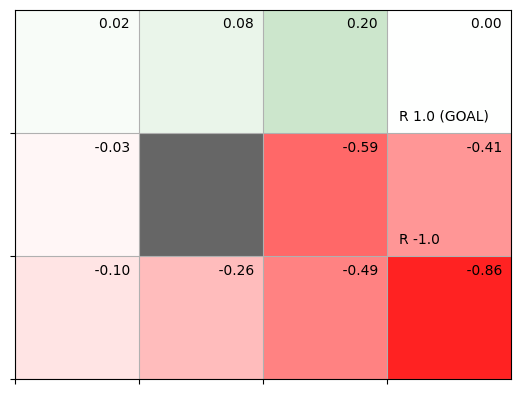

In [3]:
env = GridWorld()
agent = TdAgent()
episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_v(agent.V)

## 6.2 SARSA

### 6.2.1 同策略型的SARSA